In [1]:
%run 03_tf_dataset.ipynb

(19998, 3)
Vocabulary Size: 31
Training: 17998
Validation: 2000
(32, 100, 200, 1)
(32, 6)


In [3]:
import tensorflow as tf
import pandas as pd

from tensorflow.keras import layers
from tensorflow.keras import models

In [4]:
image_input = layers.Input(
    shape=(100, 200, 1),
    name="image"
)

In [5]:
x = layers.Conv2D(
    32,
    (3,3),
    activation="relu",
    padding="same"
)(image_input)

x = layers.MaxPooling2D(
    (2,2)
)(x)

In [6]:
x = layers.Conv2D(
    64,
    (3,3),
    activation="relu",
    padding="same"
)(x)

x = layers.MaxPooling2D(
    (2,2)
)(x)

In [7]:
# Permute to move Width (50) to the sequence/time-step dimension
x = layers.Permute(
    (2, 1, 3)
)(x)

# Now safely collapse Height (25) and Channels (64) into the feature dimension
x = layers.Reshape(
    target_shape=(50, 25 * 64)
)(x)

In [8]:
x = layers.Bidirectional(
    layers.LSTM(
        128,
        return_sequences=True
    )
)(x)

In [9]:
x = layers.Bidirectional(
    layers.LSTM(
        128,
        return_sequences=True
    )
)(x)

In [10]:
y_pred = layers.Dense(
    32,
    activation="softmax",
    name="softmax"
)(x)

In [11]:
labels = layers.Input(
    shape=(6,),
    dtype="int32",
    name="labels"
)

input_length = layers.Input(
    shape=(1,),
    dtype="int32",
    name="input_length"
)

label_length = layers.Input(
    shape=(1,),
    dtype="int32",
    name="label_length"
)

In [12]:
def ctc_loss(args):

    y_pred, labels, input_length, label_length = args

    return tf.keras.backend.ctc_batch_cost(
        labels,
        y_pred,
        input_length,
        label_length
    )

In [13]:
loss_output = layers.Lambda(
    ctc_loss,
    name="ctc_loss"
)(
    [
        y_pred,
        labels,
        input_length,
        label_length
    ]
)

In [14]:
training_model = models.Model(
    inputs=[
        image_input,
        labels,
        input_length,
        label_length
    ],
    outputs=loss_output
)

In [15]:
training_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001,
        clipnorm=1.0
    ),
    loss=lambda y_true, y_pred: y_pred
)

In [16]:
training_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)            │ (None, 100, 200, 1)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 100, 200, 32)      │             320 │ image[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 50, 100, 32)       │               0 │ conv2d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 50, 100, 64)       │          18,496 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_1               │ (None, 25, 50, 64)        │               0 │ conv2d_1[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ permute (Permute)             │ (None, 50, 25, 64)        │               0 │ max_pooling2d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reshape (Reshape)             │ (None, 50, 1600)          │               0 │ permute[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional (Bidirectional) │ (None, 50, 256)           │       1,770,496 │ reshape[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional_1               │ (None, 50, 256)           │         394,240 │ bidirectional[0][0]        │
│ (Bidirectional)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ softmax (Dense)               │ (None, 50, 32)            │           8,224 │ bidirectional_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ labels (InputLayer)           │ (None, 6)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_length (InputLayer)     │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ label_length (InputLayer)     │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ ctc_loss (Lambda)             │ (None, 1)                 │               0 │ softmax[0][0],             │
│                               │                           │                 │ labels[0][0],              │
│                               │                           │                 │ input_length[0][0],        │
│                               │                           │                 │ label_length[0][0]         │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 2,191,776 (8.36 MB)

 Trainable params: 2,191,776 (8.36 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
def prepare_for_ctc(image, label):

    batch_size = tf.shape(label)[0]

    input_length = tf.ones(
        (batch_size, 1),
        dtype=tf.int32
    ) * 50

    label_length = tf.ones(
        (batch_size, 1),
        dtype=tf.int32
    ) * 6

    inputs = {
        "image": image,
        "labels": label,
        "input_length": input_length,
        "label_length": label_length
    }

    dummy_output = tf.zeros(
        (batch_size, 1),
        dtype=tf.float32
    )

    return inputs, dummy_output

In [18]:
train_ctc_ds = train_ds.map(
    prepare_for_ctc
)

val_ctc_ds = val_ds.map(
    prepare_for_ctc
)

In [19]:
for x, y in train_ctc_ds.take(1):

    print(x["image"].shape)
    print(x["labels"].shape)
    print(x["input_length"].shape)
    print(x["label_length"].shape)
    print(y.shape)

(32, 100, 200, 1)
(32, 6)
(32, 1)
(32, 1)
(32, 1)


In [20]:
history = training_model.fit(
    train_ctc_ds,
    validation_data=val_ctc_ds,
    epochs=20
)

Epoch 1/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 173s 294ms/step - loss: 22.2672 - val_loss: 21.7351
Epoch 2/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 156s 277ms/step - loss: 21.2090 - val_loss: 20.0180
Epoch 3/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 164s 290ms/step - loss: 17.6161 - val_loss: 15.7500
Epoch 4/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 157s 277ms/step - loss: 14.0019 - val_loss: 12.5849
Epoch 5/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 156s 277ms/step - loss: 9.4221 - val_loss: 7.2830
Epoch 6/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 156s 276ms/step - loss: 5.7413 - val_loss: 4.8611
Epoch 7/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 161s 285ms/step - loss: 3.6642 - val_loss: 3.2822
Epoch 8/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 163s 288ms/step - loss: 2.4086 - val_loss: 2.4560
Epoch 9/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 165s 291ms/step - loss: 1.6756 - val_loss: 1.9512
Epoch 10/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 157s 278ms/step - loss: 1.1430 - val_loss: 1.5651
Epoch 11/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 157s 279ms/step - loss: 0.7797 - val_loss: 1.2949


In [52]:
history_continued = training_model.fit(
    train_ctc_ds,
    validation_data=val_ctc_ds,
    epochs=30,          # The total target number of epochs
    initial_epoch=20    # Tells it to start exactly where it left off
)

Epoch 21/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 189s 323ms/step - loss: 0.1242 - val_loss: 0.6563
Epoch 22/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 160s 283ms/step - loss: 0.1086 - val_loss: 0.6239
Epoch 23/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 163s 288ms/step - loss: 0.1150 - val_loss: 0.5925
Epoch 24/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 176s 311ms/step - loss: 0.1057 - val_loss: 0.6611
Epoch 25/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 163s 289ms/step - loss: 0.0877 - val_loss: 0.5505
Epoch 26/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 166s 294ms/step - loss: 0.0869 - val_loss: 0.5733
Epoch 27/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 164s 290ms/step - loss: 0.0897 - val_loss: 0.6906
Epoch 28/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 164s 290ms/step - loss: 0.0801 - val_loss: 0.5913
Epoch 29/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 164s 290ms/step - loss: 0.0792 - val_loss: 0.7400
Epoch 30/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 164s 290ms/step - loss: 0.0961 - val_loss: 0.7024


In [53]:
print(y_pred.shape)

(None, 50, 32)


In [54]:
for images, labels in train_ds.take(1):

    print(labels[0])

tf.Tensor([25 16  7 19  1 17], shape=(6,), dtype=int32)


In [55]:
prediction_model = models.Model(
    inputs=image_input,
    outputs=y_pred
)

for images, labels in val_ds.take(1):
    sample_image = images[0:1]
    sample_label = labels[0]
    break

pred = prediction_model.predict(sample_image)

decoded = np.argmax(pred[0], axis=-1)

print(decoded)
print("True label:", sample_label.numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 771ms/step
[24 11 16 16  1 13 31 31 31 31 31 31 31 31 31 31 31 31 31 31 31 31 31 31
 31 31 31 31 31 31 31 31 31 31 31 31 31 31 31 31 31  2  2 31 31 31 31 31
 31 31]
True label: [24 11 16  1 13  2]


In [56]:
history.history

{'loss': [22.26723861694336,
  21.20897674560547,
  17.616127014160156,
  14.001937866210938,
  9.422102928161621,
  5.741323471069336,
  3.6642305850982666,
  2.4086031913757324,
  1.6755822896957397,
  1.1429659128189087,
  0.7797113656997681,
  0.5331249833106995,
  0.39320454001426697,
  0.3219373822212219,
  0.2823912799358368,
  0.22020447254180908,
  0.1987285166978836,
  0.17341336607933044,
  0.16083143651485443,
  0.14389237761497498],
 'val_loss': [21.735136032104492,
  20.01797103881836,
  15.750030517578125,
  12.584930419921875,
  7.283026695251465,
  4.861138820648193,
  3.282224416732788,
  2.4560112953186035,
  1.9511674642562866,
  1.5651370286941528,
  1.2949227094650269,
  1.0436067581176758,
  0.799376904964447,
  0.8844974637031555,
  0.814582347869873,
  0.8580148220062256,
  0.8539668321609497,
  0.7645966410636902,
  0.650421679019928,
  0.7146883010864258]}

In [57]:
np.unique(decoded,return_counts=True)

(array([ 1,  2, 11, 13, 16, 24, 31]), array([ 1,  2,  1,  1,  2,  1, 42]))

In [58]:
decoded_raw = np.argmax(pred[0], axis=-1)

decoded_ctc = []

prev = -1

for x in decoded_raw:

    if x != prev:
        decoded_ctc.append(x)

    prev = x

decoded_ctc = [
    x for x in decoded_ctc
    if x != 31
]

print(decoded_ctc)
print(sample_label.numpy())

[np.int64(24), np.int64(11), np.int64(16), np.int64(1), np.int64(13), np.int64(2)]
[24 11 16  1 13  2]


In [59]:
pred_text = "".join(
    num_to_char[x]
    for x in decoded_ctc
)

true_text = "".join(
    num_to_char[int(x)]
    for x in sample_label.numpy()
)

print("Prediction:", pred_text)
print("Actual    :", true_text)

Prediction: TDJ3F4
Actual    : TDJ3F4


In [60]:
for images, labels in val_ds.take(10):

    preds = prediction_model.predict(images, verbose=0)

    break

# Testing the Model

In [61]:
def decode_prediction(pred):

    decoded_raw = np.argmax(pred, axis=-1)

    decoded_ctc = []

    prev = -1

    for x in decoded_raw:

        if x != prev:
            decoded_ctc.append(x)

        prev = x

    decoded_ctc = [
        x for x in decoded_ctc
        if x != 31
    ]

    return decoded_ctc

In [62]:
def indices_to_text(indices):

    return "".join(
        num_to_char[int(x)]
        for x in indices
    )

In [63]:
correct = 0
total = 0

for images, labels in val_ds.take(1):

    preds = prediction_model.predict(
        images,
        verbose=0
    )

    for i in range(20):

        pred_indices = decode_prediction(
            preds[i]
        )

        pred_text = indices_to_text(
            pred_indices
        )

        true_text = indices_to_text(
            labels[i].numpy()
        )

        print(
            f"Pred: {pred_text:10s} | True: {true_text}"
        )

        if pred_text == true_text:
            correct += 1

        total += 1

print()
print(
    f"Correct: {correct}/{total}"
)

Pred: TDJ3F4     | True: TDJ3F4
Pred: SEKSCT     | True: SEKSCT
Pred: 9EQ4U4     | True: 9EQ4U4
Pred: U3RBDY     | True: U3RBDY
Pred: MNYSDG     | True: MNYSDG
Pred: 3MZFG6     | True: 3MZFG6
Pred: VWNBW6     | True: VWNBW6
Pred: 8UHYWS     | True: 8UHYWS
Pred: BHVNX7     | True: BHVNX7
Pred: 3WX7WG     | True: 3WX7WG
Pred: DXDYUF     | True: DXDYUF
Pred: C8A94A     | True: C8A94A
Pred: X7K46G     | True: X7K46G
Pred: 5K7WPN     | True: 5K7WPN
Pred: D4SARD     | True: D4SARD
Pred: 6D8JGX     | True: 6D8JGX
Pred: YYPWH6     | True: YYPWH6
Pred: 3EVXEV     | True: 3EKXEV
Pred: SDX4XA     | True: SDX4XA
Pred: YC83RK     | True: YC83RK

Correct: 19/20


In [64]:
total = 0
correct = 0

for images, labels in val_ds:

    preds = prediction_model.predict(
        images,
        verbose=0
    )

    for i in range(len(labels)):

        pred_indices = decode_prediction(
            preds[i]
        )

        pred_text = indices_to_text(
            pred_indices
        )

        true_text = indices_to_text(
            labels[i].numpy()
        )

        if pred_text == true_text:
            correct += 1

        total += 1

print(f"Correct: {correct}")
print(f"Total  : {total}")
print(f"Accuracy: {100 * correct / total:.2f}%")

Correct: 1765
Total  : 2000
Accuracy: 88.25%


## Checking some Wrong Predictions

In [65]:
wrong_examples = []

for images, labels in val_ds:

    preds = prediction_model.predict(
        images,
        verbose=0
    )

    for i in range(len(labels)):

        pred_indices = decode_prediction(
            preds[i]
        )

        pred_text = indices_to_text(
            pred_indices
        )

        true_text = indices_to_text(
            labels[i].numpy()
        )

        if pred_text != true_text:

            wrong_examples.append(
                (
                    images[i].numpy(),
                    pred_text,
                    true_text
                )
            )

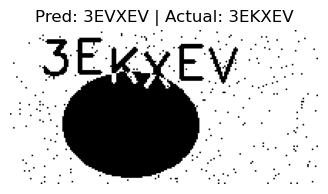

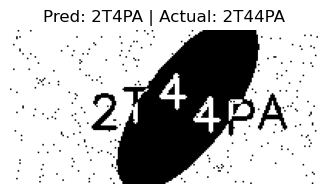

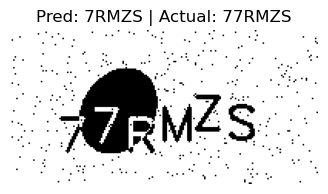

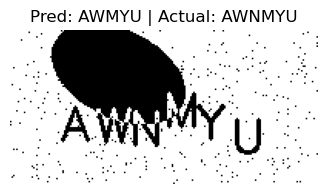

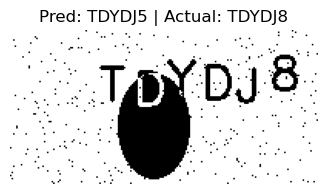

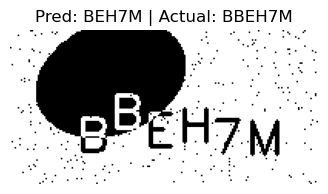

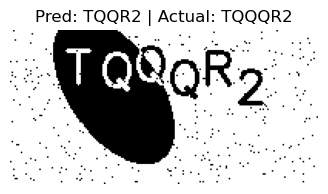

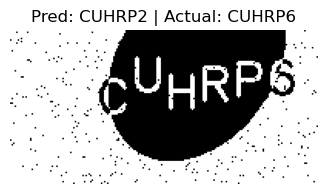

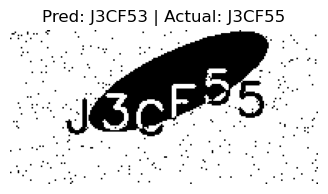

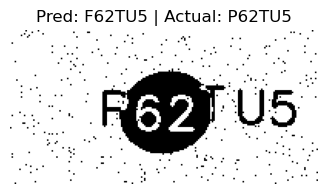

In [66]:
import matplotlib.pyplot as plt

for i in range(10):

    image, pred, actual = wrong_examples[i]

    plt.figure(figsize=(6,2))
    plt.imshow(
        image.squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Pred: {pred} | Actual: {actual}"
    )

    plt.axis("off")
    plt.show()

In [67]:
prediction_model.save("captcha_reader.keras")

In [68]:
import pickle

with open("history.pkl", "wb") as f:
    pickle.dump(history.history, f)

In [69]:
training_model.save(
    "captcha_training.keras"
)

In [41]:
!pip install python-Levenshtein

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------- ----- 1.3/1.5 MB 8.6 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 5.7 MB/s  0:00:00

   ---------------------------------------- 0/3 [rapidfuzz]
   ---------------------------------------- 0/3 [rapidfuzz]
   ---------------------------------------- 0/3 [rapidfuzz]
   ---------------------------------------- 0/3 [rapidfuzz]
   ---------------------------------------- 3/3 [python-Levenshtein]



In [71]:
from Levenshtein import distance

total_distance = 0
total_chars = 0

for images, labels in val_ds:

    preds = prediction_model.predict(
        images,
        verbose=0
    )

    for i in range(len(labels)):

        pred_indices = decode_prediction(
            preds[i]
        )

        pred_text = indices_to_text(
            pred_indices
        )

        true_text = indices_to_text(
            labels[i].numpy()
        )

        total_distance += distance(
            pred_text,
            true_text
        )

        total_chars += len(true_text)

cer = total_distance / total_chars

print(f"CER: {cer:.4f}")
print(
    f"Character Accuracy: {(1-cer)*100:.2f}%"
)

CER: 0.0204
Character Accuracy: 97.96%


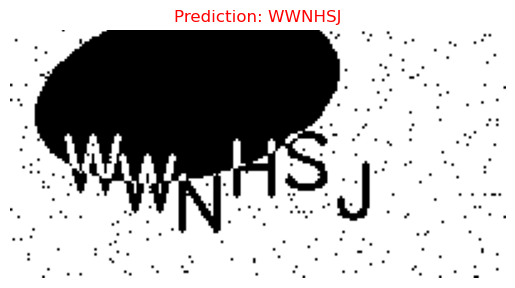

In [76]:
import matplotlib.pyplot as plt

path = r"C:\Users\ronak\OneDrive - iitr.ac.in\Desktop\CIG Captcha Reader\cig_ps\test_images\test-36.png"

img = preprocess_image(path)

pred = prediction_model.predict(
    np.expand_dims(img, axis=0),
    verbose=0
)

decoded = decode_prediction(
    pred[0]
)

text = indices_to_text(
    decoded
)

plt.imshow(
    img.squeeze(),
    cmap="gray"
)

plt.title(
    f"Prediction: {text}",
    color="red"
)

plt.axis("off")
plt.show()

In [73]:
mistakes = []

for images, labels in val_ds:

    preds = prediction_model.predict(images, verbose=0)

    for i in range(len(labels)):

        pred_text = indices_to_text(
            decode_prediction(preds[i])
        )

        true_text = indices_to_text(
            labels[i].numpy()
        )

        if pred_text != true_text:

            mistakes.append(
                (pred_text, true_text)
            )

In [75]:
for p, t in mistakes[:50]:
    print(f"{p} to {t}")

print(len(val_ds))

3EVXEV to 3EKXEV
2T4PA to 2T44PA
7RMZS to 77RMZS
AWMYU to AWNMYU
TDYDJ5 to TDYDJ8
BEH7M to BBEH7M
TQQR2 to TQQQR2
CUHRP2 to CUHRP6
J3CF53 to J3CF55
F62TU5 to P62TU5
J32PS9 to J32RS9
ZN93K to ZZN93K
86PQD to 86PQQD
TXVSX to TXVSSX
F3T82B to F3482B
7FGYYS to 7TGYYS
8DNYG7 to 8DNYC7
S4JZR to S4JJZR
3Q339G to 3Q539G
CV9C8 to CCV9C8
JDJTC to JDJTCT
E7EQJY to E2EQJY
WCDGT9 to WC9GT9
STHK3 to SSTHK3
XG56N to XGG56N
93MNS to 983MNS
CXNHGU to GXNHGU
D4TJJQ to P4TJJQ
3SPAAB to 9SPAAB
PCEMR5 to PCEMR8
SREQNN to SREQNJ
Z5ZX2 to Z55ZX2
6GS23 to 66GS23
MQ8MX to MQ8MMX
Y563SX to Y863SX
B6QZGS to BGQZGS
H8SND to H8SNND
RGWX8R to R6WX8R
9EN7SJ to 6EN7SJ
QT8VB4 to QT8V84
79DRUE to 77DRUE
J8TA84 to J8TA87
J89K4 to J889K4
UJTD9 to UUJTD9
8JUZ to 8JJJUZ
VJDBP to VJDDBP
3H9MG to 3H9MMG
R4GN35 to R4GN95
JWS6Z to JTWS6Z
YUFZ7 to YYUFZ7
63


In [77]:
with open("char_mapping.pkl", "wb") as f:

    pickle.dump(
        {
            "char_to_num": char_to_num,
            "num_to_char": num_to_char
        },
        f
    )
